In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *
from pathlib import Path 
import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [2]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = 'v22'
LUMI_SCALE = 1
# for data_year in ['2022','2023','all']:
for data_year in ['all']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig_d'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
# fpath['sig_tau'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v22/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 183102850.0
sig_d /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v22/normalized/ggH_Hto2Sto4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.root
NEvents 57931310.0
CPU times: user 534 ms, sys: 23.4 ms, total: 557 ms
Wall time: 804 ms


In [3]:
# NEvents 159888100.0
categories = ['inclusive']


# apply selections

In [4]:
%%time

selections = [0, 1, 2]    
# 0:"no selections include MB1 veto, blind DT nhit < 100": show time distributions, time spread maybe
# 1:"in-time cut + time spread": show jet, muon, MB1 ME1 veto
# 2:"jet/muon/ME1/MB1 veto": show DNN, deltaR, deltaPhi, MET
# 3:"jet/muon/ME1/MB1 veto, OOT"


selections = 3
MUON_PT_CUT = 30
JET_PT_CUT = 30
DNN_CUT = 0.96


dtRechitClusterBX = {}
cscRechitClusterMe11 = {}
cscRechitClusterMe12 = {}
cscRechitClusterJetVetoPt = {}
cscRechitClusterMuonVetoPt = {}
cscRechitClusterNStation = {}
cscRechitClusterMaxStation = {}
cscRechitClusterPhi = {}
cscRechitClusterEta = {}
cscRechitClusterDNN = {}
cscRechitClusterTime = {}
cscRechitClusterTimeSpread = {}
cscRechitClusterSize = {}
cscRechitClusterMet_dPhi = {}
cscRechitClusterGlobalMuonVetoPt = {}
cscRechitClusterMe1 = {}

dtRechitClusterMb1 = {}
dtRechitClusterJetVetoPt = {}
dtRechitClusterMuonVetoPt = {}
dtRechitClusterNStation = {}
dtRechitClusterMaxStation = {}
dtRechitClusterPhi = {}
dtRechitClusterEta = {}
dtRechitClusterSize = {}
dtRechitClusterMet_dPhi = {}

deltaPhi_cluster = {}
sel_ev = {} 
nJets = {}
jetPt = {}
met = {}
Puppimet = {}
runNum = {}
HMTEff = {}
weight = {}
categories = ['NStation3', 'NStation4']
categories = ['lowMET', 'highMET']
categories = ['inclusive']
region_list = ['oot', 'signal']
CSC_THRESHOLD = [160,80]
for tree_k in tree.keys():
    T = tree[tree_k]
    for met_cat in categories:
        k = f'{tree_k}_{met_cat}'
        ########### SELECTION: CLUSTERS ############
        me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
        T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())
        cscRechitClusterR = (T['cscRechitClusterX'].array()**2+T['cscRechitClusterY'].array()**2)**0.5
        L1 = L1_trg(cscRechitClusterR, np.abs(T['cscRechitClusterZ'].array()), np.abs(T['cscRechitClusterSize'].array()))

        #one cluster to pass trigger
        if selections >= 0:
            if "data" in k:
                csccluster = T['cscRechitClusterSize'].array()>=0
                dtcluster = (T['dtRechitClusterNHitStation1'].array()==0)
            else:
                csccluster = T['cscRechitCluster_match_gLLP'].array()
                dtcluster = T['dtRechitCluster_match_gLLP'].array() & (T['dtRechitClusterNHitStation1'].array()==0)
        if "data" in k and (not selections == 3): 
                dtcluster = dtcluster & (T['dtRechitClusterSize'].array()<100)
        if selections >= 1:
            csccluster = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            csccluster = csccluster & (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)
            
        if selections == 1 or selections == 2:
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPCBx_dPhi0p5'].array() == 0)
        elif "data" in k and selections == 3:
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPChits_dPhi0p5'].array() >= 1)
            dtcluster = dtcluster & (T['dtRechitCluster_match_RPCBx_dPhi0p5'].array() < 0)
        
        if selections >= 2:
            csccluster = csccluster & (T['cscRechitClusterJetVetoPt'].array()<30)
            csccluster = csccluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > 30) & T['cscRechitClusterMuonVetoGlobal'].array())    
            csccluster = csccluster & (me1 ==0)
            dtcluster = dtcluster & (T['dtRechitClusterJetVetoPt'].array()<30)
            dtcluster = dtcluster & np.logical_not((T['dtRechitClusterMuonVetoPt'].array() > 30) & T['dtRechitClusterMuonVetoLooseId'].array())
    




    ########### SELECTION: EVENTS ############
        sel_ev[k] = T['HLT_CSCDT'].array()
        sel_ev[k] = np.logical_and(sel_ev[k] ,T['Flag_all'].array())
        sel_ev[k] = sel_ev[k] & (T['nCscRechitClusters'].array()==1) & (T['nDtRechitClusters'].array()==1)
        sel_ev[k] = np.logical_and(sel_ev[k] ,T['met'].array() < 200)
        sel_ev[k]  = sel_ev[k] & (np.sum(dtcluster, axis = 1) == 1)
        sel_ev[k]  = sel_ev[k] & (np.sum(csccluster, axis = 1) == 1)
        print(k, np.count_nonzero(sel_ev[k]))
    ########### BRANCHES ############

       ##### event variables ##### 
        # make sure cluster0 and cluster1 index are different
        cscRechitClusterMe11[k] = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberMinus11'].array())[csccluster][sel_ev[k]][:,0]
        cscRechitClusterMe12[k] = (T['cscRechitClusterNRechitChamberPlus12'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())[csccluster][sel_ev[k]][:,0]
        cscRechitClusterMe1[k] = cscRechitClusterMe11[k] + cscRechitClusterMe12[k]
        cscRechitClusterJetVetoPt[k] = T['cscRechitClusterJetVetoPt'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterMuonVetoPt[k] = T['cscRechitClusterMuonVetoPt'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterGlobalMuonVetoPt[k] = (T['cscRechitClusterMuonVetoPt'].array()*T['cscRechitClusterMuonVetoGlobal'].array())[csccluster][sel_ev[k]][:,0]
        cscRechitClusterNStation[k] = T['cscRechitClusterNStation10'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterMaxStation[k] = T['cscRechitClusterMaxStation'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterDNN[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterTime[k] = T['cscRechitClusterTimeWeighted'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterTimeSpread[k] = T['cscRechitClusterTimeSpreadWeightedAll'].array()[csccluster][sel_ev[k]][:,0]
        cscRechitClusterSize[k] = T['cscRechitClusterSize'].array()[csccluster][sel_ev[k]][:,0]

        dtRechitClusterMb1[k] = T['dtRechitClusterNHitStation1'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterJetVetoPt[k] = T['dtRechitClusterJetVetoPt'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterMuonVetoPt[k] = (T['dtRechitClusterMuonVetoPt'].array()*T['dtRechitClusterMuonVetoLooseId'].array())[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterNStation[k] = T['dtRechitClusterNStation10'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterMaxStation[k] = T['dtRechitClusterMaxStation'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterPhi[k] = T['dtRechitClusterPhi'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterEta[k] = T['dtRechitClusterEta'].array()[dtcluster][sel_ev[k]][:,0]
        dtRechitClusterSize[k] = T['dtRechitClusterSize'].array()[dtcluster][sel_ev[k]][:,0]

        dtRechitClusterBX[k] = T['dtRechitCluster_match_RPCBx_dPhi0p5'].array()[dtcluster][sel_ev[k]][:,0]

        
        deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi[k]), np.array(dtRechitClusterPhi[k]))
        met[k] = T['met'].array()[sel_ev[k]]
        Puppimet[k] = T['Puppimet'].array()[sel_ev[k]]


        # sel[k] = (np.abs(deltaPhi_cluster[k])>0.4)
        print(k, np.count_nonzero((np.abs(deltaPhi_cluster[k])>0.4))/len((deltaPhi_cluster[k])))
        # deltaPhi_cluster[k] = deltaPhi_cluster[k][sel[k]]
        # dtRechitClusterSize[k] = dtRechitClusterSize[k][sel[k]]

        HMTEff = T['cscRechitClusterHMTEfficiency'].array()[csccluster][sel_ev[k]][:,0]
        if 'data' in k:weight[k] = (T['weight'].array())[sel_ev[k]]* 0.0 + 1
        else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev[k]]*HMTEff*LUMI_SCALE


dataall_inclusive 29096
dataall_inclusive 0.6019727797635414
sig_d_inclusive 4000
sig_d_inclusive 0.9825
CPU times: user 14.4 s, sys: 2.57 s, total: 16.9 s
Wall time: 26.9 s


In [5]:
variables = {
'cscRechitClusterMe11': ['CSC cluster N_{ME11 hits}', cscRechitClusterMe11, [50,0,50], True],
'cscRechitClusterMe12': ['CSC cluster N_{ME12 hits}', cscRechitClusterMe12, [50,0,50], True],
'cscRechitClusterMe1': ['CSC cluster N_{ME11/12 hits}', cscRechitClusterMe1, [50,0,50], True],
'cscRechitClusterJetVetoPt': ['CSC cluster jet veto p_{T} [GeV]', cscRechitClusterJetVetoPt, [30,0,300], True],
'cscRechitClusterGlobalMuonVetoPt': ['CSC cluster muon veto p_{T} [GeV]', cscRechitClusterGlobalMuonVetoPt, [30,0,300], True],
'cscRechitClusterNStation': ['CSC cluster  N_{stations}', cscRechitClusterNStation, [5,0,5], True],
'cscRechitClusterPhi': ['CSC cluster #phi', cscRechitClusterPhi, [50,-3.5,3.5], True],
'cscRechitClusterEta': ['CSC cluster #eta', cscRechitClusterEta, [50,-3,3], True],
'cscRechitClusterDNN': ['CSC cluster DNN score', cscRechitClusterDNN, [50,0,1], True],
'cscRechitClusterTime': ['CSC cluster time [ns]', cscRechitClusterTime, [50,-100,100], False],
'cscRechitClusterTimeSpread': ['CSC cluster time spread [ns]', cscRechitClusterTimeSpread, [50,0,50], True],
'cscRechitClusterSize': ['CSC cluster N_{hits}', cscRechitClusterSize, [50,0,500], True],
'cscRechitClusterMet_dPhi': ['#Delta#phi(MET, cluster)', cscRechitClusterMet_dPhi, [25,0,3.2], True],

'dtRechitClusterMb1': ['DT cluster N_{MB1 hits}', dtRechitClusterMb1, [50,0,50], True],
'dtRechitClusterJetVetoPt': ['DT cluster jet veto p_{T} [GeV]', dtRechitClusterJetVetoPt, [50,0,500], True],
'dtRechitClusterMuonVetoPt': ['DT cluster muon veto p_{T} [GeV]', dtRechitClusterMuonVetoPt, [50,0,500], True],
'dtRechitClusterNStation': ['DT cluster N_{stations}', dtRechitClusterNStation, [5,0,5], True],
'dtRechitClusterPhi': ['DT cluster #phi', dtRechitClusterPhi, [50,-3.5,3.5], True],
'dtRechitClusterEta': ['DT cluster #eta', dtRechitClusterEta, [50,-3,3], True],
'dtRechitClusterSize': ['DT cluster N_{hits}', dtRechitClusterSize, [50,0,500], True],
'dtRechitClusterBX': ['DT cluster bunch crossing', dtRechitClusterBX, [10,-5,5], False],
'deltaPhi_cluster': ['#Delta#phi(cluster 1, cluster 2)', deltaPhi_cluster, [25,0,3.2], True],
# 'deltaR_cluster': ['#Delta R(cluster 1, cluster 2)', deltaR_cluster, [50,0,5], True],
'met': ['MET [GeV]',met,[50,0,200],True],
'Puppimet': ['MET [GeV]',Puppimet,[50,0,200],True],

}


plot_dir = GIT_REPO + f"/plots/selections_dtcsc_{selections}/"
Path(plot_dir).mkdir(parents=True, exist_ok=True)

## Plot distributions

cscRechitClusterMe11
cscRechitClusterMe12
cscRechitClusterMe1
cscRechitClusterJetVetoPt
cscRechitClusterGlobalMuonVetoPt
cscRechitClusterNStation
cscRechitClusterPhi
cscRechitClusterEta
cscRechitClusterDNN
cscRechitClusterTime
cscRechitClusterTimeSpread
cscRechitClusterSize
cscRechitClusterMet_dPhi
dtRechitClusterMb1
dtRechitClusterJetVetoPt
dtRechitClusterMuonVetoPt
dtRechitClusterNStation
dtRechitClusterPhi
dtRechitClusterEta
dtRechitClusterSize
dtRechitClusterBX
deltaPhi_cluster
met
Puppimet
1.3221540451049805


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_dtcsc_3//cscRechitClusterMe11.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_dtcsc_3//cscRechitClusterMe11.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_dtcsc_3//cscRechitClusterMe11.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_dtc

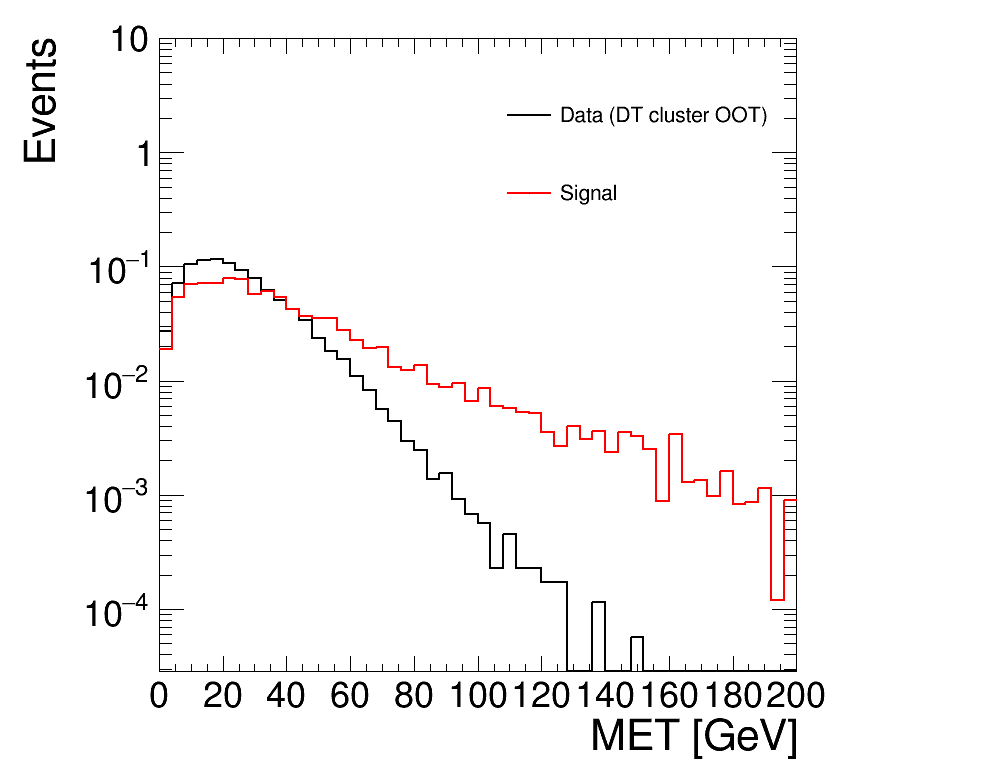

In [9]:

start_t = time.time()
for name, v in variables.items():
    # if not "cscRechitClusterSize" in name:continue
    c = rt.TCanvas('c','c', 1000, 800)
    h = {}
    if selections == 3:leg = rt.TLegend(0.5,0.7,0.75,0.9)
    else: leg = rt.TLegend(0.6,0.7,0.75,0.9)
    leg.SetTextSize(0.03)
    leg.SetTextFont(42)
    leg.SetBorderSize(0)
    xaxis, plot_var, bins, logy = v
    i = 0
    print(name)
    for k in plot_var.keys():

        cond = np.abs(deltaPhi_cluster[k])>=0.4
        # if "data" in k and selections >= 2:
        h[k] = create_TH1D( np.array(plot_var[k][cond]), axis_title = [xaxis,'Events'], binning=bins,weights = np.array(weight[k][cond]))
        
        h[k].Scale(1./h[k].Integral())
        if logy: h[k].SetMaximum(10)
        else: h[k].SetMaximum(1.2)

        h[k].SetLineColor(std_color_list[i])
        if "data" in k and selections >= 3:leg.AddEntry(h[k],'Data (DT cluster OOT)')
        elif "data" in k: leg.AddEntry(h[k],"Data")
        else: leg.AddEntry(h[k],"Signal")
        h[k].Draw('hist same')
        i+=1
    c.SetRightMargin(0.2)

    if logy: c.SetLogy()
    leg.Draw()
    c.Draw()

    c.SaveAs(plot_dir + f"/{name}.png")
    c.SaveAs(plot_dir + f"/{name}.pdf")
    c.SaveAs(plot_dir + f"/{name}.C")

print(time.time()-start_t)


0.008992433547973633


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


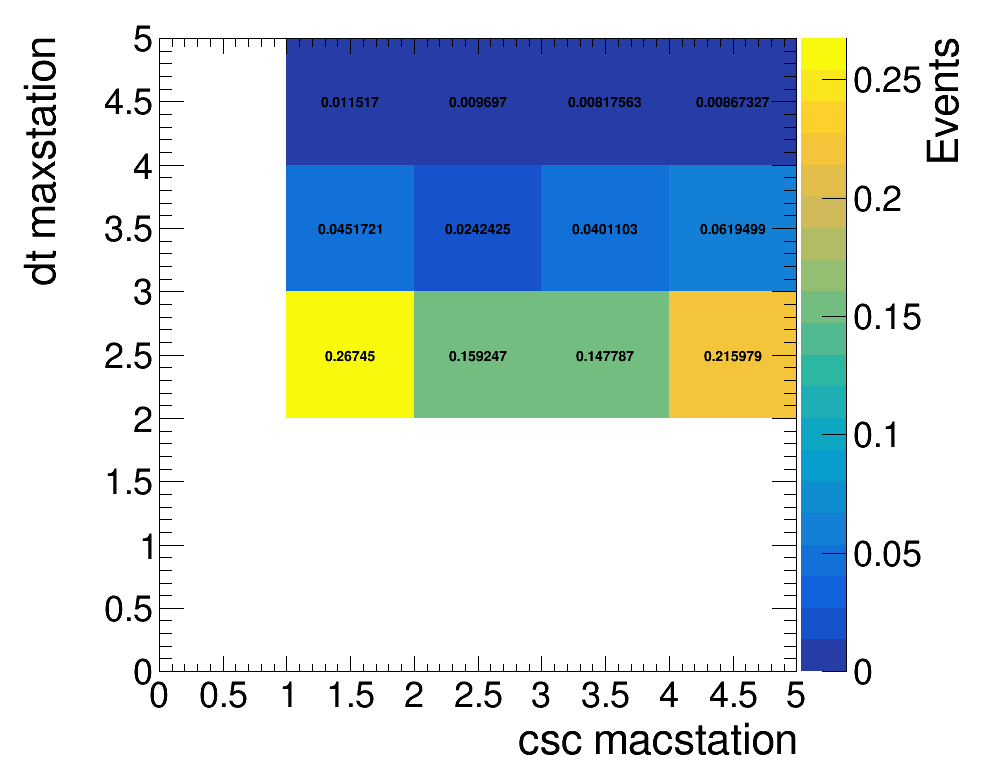

In [57]:
# Plotting ncsc
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
# plot_var = [cscRechitClusterSize1, deltaPhi_cluster]
# axis = ['N_{rechits}','#Delta#phi',]
# name = ['nhits','dphi']
# bins = [[25,50,500],[25,1.8,3.2]]


k = "signal_dataall_lowMET"
h = create_TH2D(np.column_stack(( np.array(cscRechitClusterNStation[k]), np.abs(np.array(dtRechitClusterMaxStation[k])))),\
               axis_title = ['csc nstation','dt maxstation','Events'], binning=[5,0,5,5,0,5])
h = create_TH2D(np.column_stack(( np.abs(np.array(cscRechitClusterMaxStation[k])), np.abs(np.array(dtRechitClusterMaxStation[k])))),\
               axis_title = ['csc macstation','dt maxstation','Events'], binning=[5,0,5,5,0,5])
h.DrawNormalized('colz text')

# print(np.min(runNum[k]),np.max(runNum[k]))
# h = create_TH1D( np.array(runNum[k]), axis_title = ['run number','Events'], binning=[5000,360000,371000])
# h.Draw()
# h[k].SetLineColor(std_color_list[i])
# leg.AddEntry(h[k],k.replace('all',''))

c.SetRightMargin(0.2)

c.Draw()

# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".png")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".pdf")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".C")




print(time.time()-start_t)

In [49]:
cscRechitClusterNStation.keys()

dict_keys(['oot_dataall_lowMET', 'oot_dataall_highMET', 'signal_dataall_lowMET', 'signal_dataall_highMET', 'signal_sig_b_lowMET', 'signal_sig_b_highMET'])

# 2D plots

In [64]:
# Plotting ncsc
start_t = time.time()
for name, v in variables.items():
    plot_var, bins, logy = v
    # if not name == "cscRechitClusterNStation":continue
    for k in plot_var.keys():
        print(k)
        c = rt.TCanvas('c','c', 1000, 800)
        h = {}

        
        i = 0
        print(name)

        if 'invertDNN_sig' in k or 'oot_sig' in k:continue
        cond = np.abs(deltaPhi_cluster[k])>=0
        if selections >= 3:
            cond = cond & (np.abs(deltaPhi_cluster[k]) > 1.8)
            cond = cond & (deltaR_cluster[k] < 3.5)
            if 'data' in k:
                cond = cond & (cscRechitClusterTime[k][:,0] < 12.5) & (cscRechitClusterTime[k][:,0] > -5)
                cond = cond & ((cscRechitClusterTime[k][:,1] >= 12.5) | (cscRechitClusterTime[k][:,1] < -5))

        if plot_var[k].ndim == 2:
            h[k] = create_TH2D( np.column_stack((np.array(plot_var[k][cond][:,0]), np.array(plot_var[k][cond][:,1]))), \
                                                 axis_title = [f"{name}_0",f"{name}_1", 'Events'], binning=bins*2,weights = np.array(weight[k][cond]))
        else:
            print("here")
            continue
        h[k].Scale(1./h[k].Integral())
        h[k].SetMaximum(10)

        h[k].SetLineColor(std_color_list[i])
        if "data" in k and selections >= 3:leg.AddEntry(h[k],'Data (2nd cluster OOT)')
        elif "data" in k: leg.AddEntry(h[k],'Data')
        else: leg.AddEntry(h[k],k.replace('_inclusive',''))
        h[k].Draw('colz')
        i+=1
        c.SetRightMargin(0.2)

        if logy: c.SetLogz()
        c.Draw('colz')

        c.SaveAs(plot_dir + f"/{name}_{k}_2d.png")
        c.SaveAs(plot_dir + f"/{name}_{k}_2d.pdf")
        c.SaveAs(plot_dir + f"/{name}_{k}_2d.C")
    # break


print(time.time()-start_t)


dataall_inclusive
cscRechitClusterMe11
sig_b_inclusive
cscRechitClusterMe11
sig_tau_inclusive
cscRechitClusterMe11
dataall_inclusive
cscRechitClusterMe12
sig_b_inclusive
cscRechitClusterMe12
sig_tau_inclusive
cscRechitClusterMe12
dataall_inclusive
cscRechitClusterJetVetoPt
sig_b_inclusive
cscRechitClusterJetVetoPt
sig_tau_inclusive
cscRechitClusterJetVetoPt
dataall_inclusive
cscRechitClusterMuonVetoPt
sig_b_inclusive
cscRechitClusterMuonVetoPt
sig_tau_inclusive
cscRechitClusterMuonVetoPt
dataall_inclusive
cscRechitClusterNStation
sig_b_inclusive
cscRechitClusterNStation
sig_tau_inclusive
cscRechitClusterNStation
dataall_inclusive
cscRechitClusterPhi
sig_b_inclusive
cscRechitClusterPhi
sig_tau_inclusive
cscRechitClusterPhi
dataall_inclusive
cscRechitClusterEta
sig_b_inclusive
cscRechitClusterEta
sig_tau_inclusive
cscRechitClusterEta
dataall_inclusive
cscRechitClusterDNN
sig_b_inclusive
cscRechitClusterDNN
sig_tau_inclusive
cscRechitClusterDNN
dataall_inclusive
cscRechitClusterTime
sig_b

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_csccsc_3//cscRechitClusterMe11_dataall_inclusive_2d.png has been created
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_csccsc_3//cscRechitClusterMe11_dataall_inclusive_2d.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_csccsc_3//cscRechitClusterMe11_dataall_inclusive_2d.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/selections_csccsc_3//cscRechitClusterMe11_sig_b_inclusive_2d.png has been created
Info in <TCanvas::Print>